In [15]:
# Download ProPainter from GitHub
!git clone https://github.com/sczhou/ProPainter.git
%cd ProPainter

# Install the required libraries
!pip install torch torchvision
!pip install -r requirements.txt
!pip install opencv-python

Cloning into 'ProPainter'...
remote: Enumerating objects: 615, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 615 (delta 88), reused 70 (delta 70), pack-reused 474 (from 2)
Receiving objects: 100% (615/615), 69.84 MiB | 23.86 MiB/s, done.
Resolving deltas: 100% (100/100), done.
/content/ProPainter/ProPainter


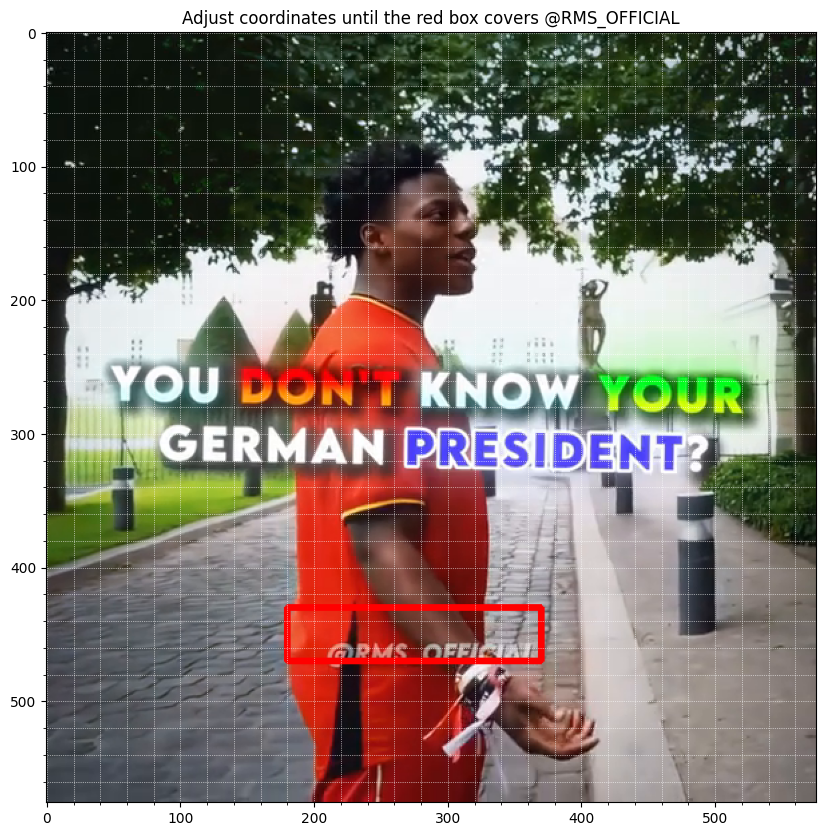

In [26]:
import cv2
import matplotlib.pyplot as plt
import glob

# Try your coordinates here
X_START = 180
Y_START = 430
WIDTH = 190
HEIGHT = 40

# Load the first frame of your video
frames = glob.glob("/content/**/inputs/frames/*.png", recursive=True)
if not frames:
    print("❌ ERROR: Frames not found. Did you run Cell 2?")
else:
    img = cv2.imread(frames[0])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Draw a RED box using your coordinates
    cv2.rectangle(img, (X_START, Y_START), (X_START + WIDTH, Y_START + HEIGHT), (255, 0, 0), 3)

    # Display the image with pixel rulers
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.title("Adjust coordinates until the red box covers @RMS_OFFICIAL")
    # Turn on axes so you can read the exact pixel numbers
    plt.minorticks_on()
    plt.grid(which='both', color='white', linestyle=':', linewidth=0.5)
    plt.show()

In [27]:
import os
import subprocess
import cv2

def prepare_video_and_masks(video_path, frames_dir, masks_dir, x, y, width, height):
    print("1. Extracting frames...")
    os.makedirs(frames_dir, exist_ok=True)
    os.makedirs(masks_dir, exist_ok=True)

    # Extract audio (so we can add it back later)
    subprocess.run(['ffmpeg', '-y', '-i', video_path, '-q:a', '0', '-map', 'a', 'audio.wav'])
    # Extract frames
    subprocess.run(['ffmpeg', '-y', '-i', video_path, os.path.join(frames_dir, '%04d.png')])

    print("2. Generating AI Masks...")
    for frame_name in sorted(os.listdir(frames_dir)):
        if not frame_name.endswith('.png'): continue

        frame_path = os.path.join(frames_dir, frame_name)
        img = cv2.imread(frame_path)

        # Create a black mask of the same dimensions
        mask = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        mask[:, :] = 0

        # Draw a white rectangle over the watermark
        cv2.rectangle(mask, (x, y), (x + width, y + height), (255, 255, 255), -1)
        cv2.imwrite(os.path.join(masks_dir, frame_name), mask)
    print("Done! Ready for AI Inpainting.")

# --- ADJUST THESE COORDINATES FOR YOUR WATERMARK ---
X_START = 180 # Distance from left edge
Y_START = 430  # Distance from top edge
WIDTH = 190  # Width of watermark
HEIGHT = 50    # Height of watermark
# ---------------------------------------------------

prepare_video_and_masks("input_video.mp4", "inputs/frames", "inputs/masks", X_START, Y_START, WIDTH, HEIGHT)

1. Extracting frames...
2. Generating AI Masks...
Done! Ready for AI Inpainting.


In [28]:
import os
import glob
import subprocess

print("🔍 Locating the correct folders...")

# Search for the inference script wherever it ended up
script_paths = glob.glob("/content/**/inference_propainter.py", recursive=True)
if not script_paths:
    raise FileNotFoundError("❌ ERROR: Could not find ProPainter. Please re-run Cell 1.")
script_path = script_paths[0]
script_dir = os.path.dirname(script_path)

# Search for the extracted frames folder
frames_paths = glob.glob("/content/**/inputs/frames", recursive=True)
if not frames_paths:
    raise FileNotFoundError("❌ ERROR: Could not find the frames folder. Please re-run Cell 2.")
frames_dir = frames_paths[0]
masks_dir = frames_dir.replace("frames", "masks")
results_dir = os.path.join(script_dir, "results")

print(f"✅ Found script at: {script_path}")
print(f"✅ Found frames at: {frames_dir}")

print("🎬 Running ProPainter AI (this will take a few minutes)...")

# Force Colab into the correct directory before running
os.chdir(script_dir)

# Run the memory-optimized AI command
subprocess.run([
    'python', 'inference_propainter.py',
    '--video', frames_dir,
    '--mask', masks_dir,
    '--output', results_dir,
    '--fp16',
    '--subvideo_length', '40',
    '--resize_ratio', '0.5'
])

print("✅ Done! If you don't see any red CUDA memory errors above, move on to Cell 4.")

🔍 Locating the correct folders...
✅ Found script at: /content/ProPainter/inference_propainter.py
✅ Found frames at: /content/ProPainter/inputs/frames
🎬 Running ProPainter AI (this will take a few minutes)...
✅ Done! If you don't see any red CUDA memory errors above, move on to Cell 4.


In [29]:
import subprocess
import os
import glob
from google.colab import files

print("🔍 Searching for ProPainter's output video...")

base_dir = "/content/ProPainter"
results_dir = os.path.join(base_dir, "results")
audio_file = os.path.join(base_dir, "audio.wav")
final_video = os.path.join(base_dir, "final_clean_video.mp4")

if not os.path.exists(results_dir):
    raise FileNotFoundError("❌ ERROR: The 'results' folder does not exist. Did Cell 3 fail or not finish?")

# Dynamically search the entire results folder for ANY .mp4 file
found_videos = glob.glob(os.path.join(results_dir, "**", "*.mp4"), recursive=True)

if not found_videos:
    raise FileNotFoundError("❌ ERROR: Could not find any .mp4 files inside the 'results' folder. The AI might not have finished processing.")

# Use the first video it finds (which will be inpaint_out.mp4)
video_without_audio = found_videos[0]
print(f"✅ Found repaired video at: {video_without_audio}")

if not os.path.exists(audio_file):
    print("⚠️ WARNING: Audio file not found. The final video will be silent.")
    subprocess.run(['cp', video_without_audio, final_video])
else:
    print("🎬 Merging original audio with the repaired video...")
    result = subprocess.run([
        'ffmpeg', '-y', '-i', video_without_audio, '-i', audio_file,
        '-c:v', 'copy', '-c:a', 'aac', '-strict', 'experimental', final_video
    ], capture_output=True, text=True)

if not os.path.exists(final_video):
    print("❌ ERROR: FFmpeg failed to merge audio. Here is the hidden error log:")
    print(result.stderr)
else:
    print("✅ Success! The final video is ready.")
    files.download(final_video)


🔍 Searching for ProPainter's output video...
✅ Found repaired video at: /content/ProPainter/results/frames/inpaint_out.mp4
🎬 Merging original audio with the repaired video...
✅ Success! The final video is ready.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>